In [1]:
# Test order of interp by plotting (interp err) vs nx

In [2]:
%reset -f
%run interp_defs.ipynb


In [3]:
# three different interpolations
# options = {'method': 'linear'} # very fast
# options = {'method': 'cubic', 'solver_args': {'rtol': 1e-14}} # slow
# options = {'method': 'cubic', 'solver': spsolve} # very slow

import time
import matplotlib.pyplot as plt 

# function for testing the 2D interpolation 
cf1 = 1; cf2 = 0.5
def f_test(x, y):
    x, y = torch.broadcast_tensors(torch.as_tensor(x), torch.as_tensor(y))
    # This is to make it work when x or y is a numpy array or a scalar
    return torch.cos(cf1*(x+y-1))*torch.cos(cf2*(x-y))

# 2D points for testing the 2D interpolation 
nq = 20000
xq = torch.rand(nq, device=device)
yq = torch.rand(nq, device=device)

nx_A = 4*2**np.arange(8)
err_A = 0.0*nx_A

start_time = time.perf_counter()
options = {'method': 'linear'} # very fast
for k, nx in enumerate(nx_A):
    err_A[k] = err_of_interp(f_test, nx, **options)[0]
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f'options = {options},')
print(f'ellapsed time = {elapsed_time:.4f}s')
err_op1_A = err_A.copy()

start_time = time.perf_counter()
options = {'method': 'cubic', 'solver_args': {'rtol': 1e-14}} # slow
for k, nx in enumerate(nx_A):
    err_A[k] = err_of_interp(f_test, nx, **options)[0]
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f'options = {options},')
print(f'ellapsed time = {elapsed_time:.4f}s')
err_op2_A = err_A.copy()

start_time = time.perf_counter()
options = {'method': 'cubic', 'solver': spsolve} # very slow
for k, nx in enumerate(nx_A):
    err_A[k] = err_of_interp(f_test, nx, **options)[0]
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f'options = {options},')
print(f'ellapsed time = {elapsed_time:.4f}s')
err_op3_A = err_A.copy()


options = {'method': 'linear'},
ellapsed time = 0.0675s
options = {'method': 'cubic', 'solver_args': {'rtol': 1e-14}},
ellapsed time = 1.4000s
options = {'method': 'cubic', 'solver': <function spsolve at 0x7c703cadf420>},
ellapsed time = 34.8705s


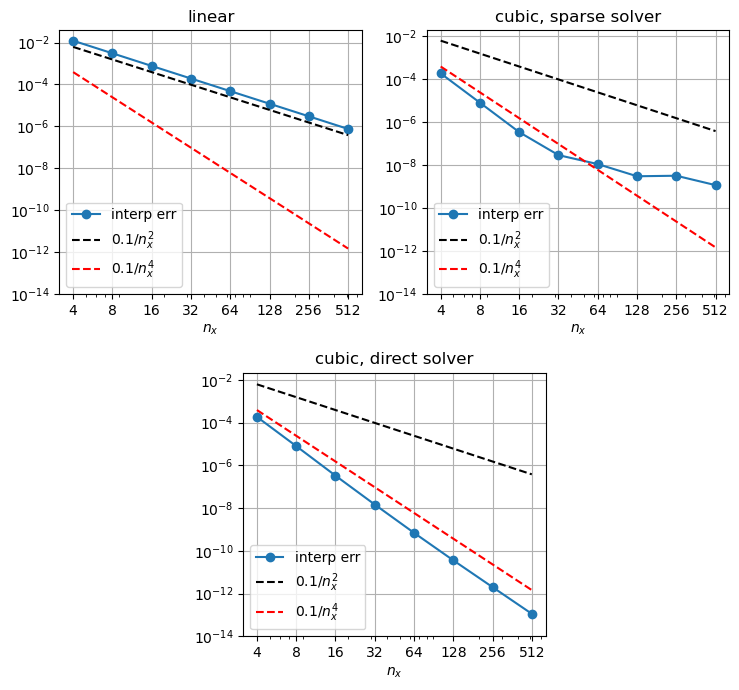

In [4]:
fig = plt.figure(figsize=(7.5, 7))
gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])   # centered

ax = ax1; err_A = err_op1_A; title = 'linear'
ax.loglog(nx_A, err_A, '-o', label=r'interp err')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-2), 'k--', label=r'$0.1/n_x^2$')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-4), 'r--', label=r'$0.1/n_x^4$')
ax.set_xlabel(r'$n_x$')
ax.set_yticks(10.0**np.arange(-14,-1,2))
ax.set_xticks(nx_A, [str(int(x)) for x in nx_A])
ax.set_title(title)
ax.legend()
ax.grid(True)

ax = ax2; err_A = err_op2_A; title = 'cubic, sparse solver'
ax.loglog(nx_A, err_A, '-o', label=r'interp err')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-2), 'k--', label=r'$0.1/n_x^2$')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-4), 'r--', label=r'$0.1/n_x^4$')
ax.set_xlabel(r'$n_x$')
ax.set_yticks(10.0**np.arange(-14,-1,2))
ax.set_xticks(nx_A, [str(int(x)) for x in nx_A])
ax.set_title(title)
ax.legend()
ax.grid(True)

ax = ax3; err_A = err_op3_A; title = 'cubic, direct solver'
ax.loglog(nx_A, err_A, '-o', label=r'interp err')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-2), 'k--', label=r'$0.1/n_x^2$')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-4), 'r--', label=r'$0.1/n_x^4$')
ax.set_xlabel(r'$n_x$')
ax.set_yticks(10.0**np.arange(-14,-1,2))
ax.set_xticks(nx_A, [str(int(x)) for x in nx_A])
ax.set_title(title)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# plt.savefig("fig_n1A_wd6_Long.pdf", format="pdf", bbox_inches='tight')